In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
image1 = cv2.imread('pexels-alexravvas-26611787.jpg', cv2.IMREAD_GRAYSCALE)
image1 = cv2.resize(image1,(500,500))
image2 = image1.copy()

In [ ]:
def apply_convolutional(image,kernel):
    h,w = image.shape
    k_h,k_w = kernel.shape
    pad_h = k_h//2
    pad_w = k_w//2
    padded_image = np.pad(image,((pad_h, pad_h),(pad_w, pad_w)), mode='edge')
    output_image = np.zeros_like(image, dtype = float)
    for i in range(h):
        for j in range(w):
            region = padded_image[i:i+k_h, j:j+k_w]
            output_image[i,j] = np.sum(region * kernel)
    return output_image
        
        
        


In [ ]:
def sobel_edge_detection(image):
    image = np.array(image,dtype = float)
    kernel_x = np.array([
        [-1,0,1],
        [-2,0,2],
        [-1,0,1]
    ])
    kernel_y = np.array([
        [1,2,1],
        [0,0,0],
        [-1,-2,-1]
    ])
    Gx = apply_convolutional(image,kernel_x)
    Gy = apply_convolutional(image,kernel_y)    
    magnitude = np.sqrt(Gx**2 + Gy**2)
    magnitude = (magnitude / np.max(magnitude)) * 255
    output_image = magnitude.astype(np.uint8)
    return Gx,Gy ,output_image





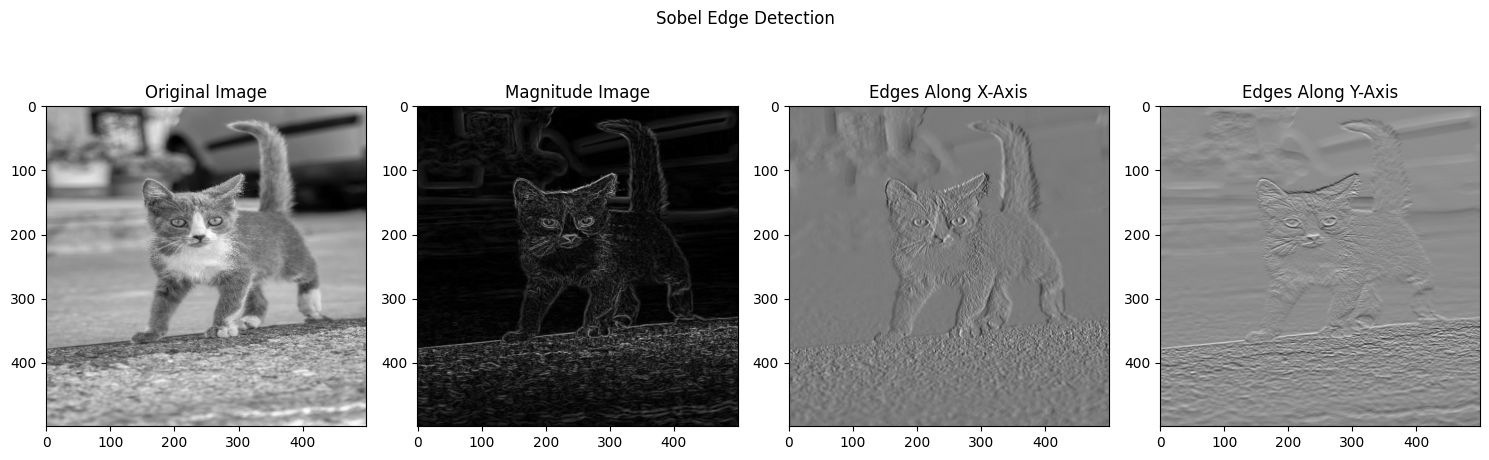

In [ ]:
GX, GY , image3 = sobel_edge_detection(image2)
plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.imshow(image1, cmap = 'gray')
plt.title('Original Image')
plt.subplot(1,4,2)
plt.imshow(image3 , cmap = 'gray')
plt.title('Magnitude Image')
plt.subplot(1,4,3)
plt.imshow(GX , cmap = 'gray')
plt.title("Edges Along X-Axis")
plt.subplot(1,4,4)
plt.imshow(GY, cmap = 'gray')
plt.title("Edges Along Y-Axis")
plt.suptitle("Sobel Edge Detection")
plt.tight_layout()
plt.show()




In [ ]:
sobelx = cv2.Sobel(image2, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(image2, cv2.CV_64F, 0, 1, ksize=3)
sobel_magnitude = cv2.magnitude(sobelx, sobely)
sobel_magnitude = cv2.convertScaleAbs(sobel_magnitude)

plt.figure(figsize=(15,5))
plt.subplot(1,4,1)
plt.imshow(image1, cmap = 'gray')
plt.title('Original Image')
plt.subplot(1,4,2)
plt.imshow(sobel_magnitude , cmap = 'gray')
plt.title('Magnitude Image')
plt.subplot(1,4,3)
plt.imshow(sobelx , cmap = 'gray')
plt.title("Edges Along X-Axis")
plt.subplot(1,4,4)
plt.imshow(sobely, cmap = 'gray')
plt.title("Edges Along Y-Axis")
plt.suptitle("Sobel Edge Detection Using CV2")
plt.tight_layout()
plt.show()


In [ ]:
# Tasks
# 1. Change Kernel Size (7,7),(15,15),(19,19)
# 2. Change Code to Use Prewit and Cross Operators
# 3. Implement Prewit and Cross Edge Detectors By Adding Changes In The Code
# 4. Display The Results of all edge detectors in a single figure with appropriate titles and labels.